# Architecture of filters

So, the english is not very good, I will improve that

In [448]:
import itertools

import sympy as sy
import numpy as np

from sympy import init_printing, I
init_printing(use_latex='png', forecolor='White', backcolor='Black')


In [111]:
import fitz

from utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution, winograd_cyclic_conv2x2

In [112]:
doc = fitz.open('Diaz-Perez_Rodriguez_2006_One Dimensional Cyclic Convolution Algorithms with Minimal Multiplicative.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

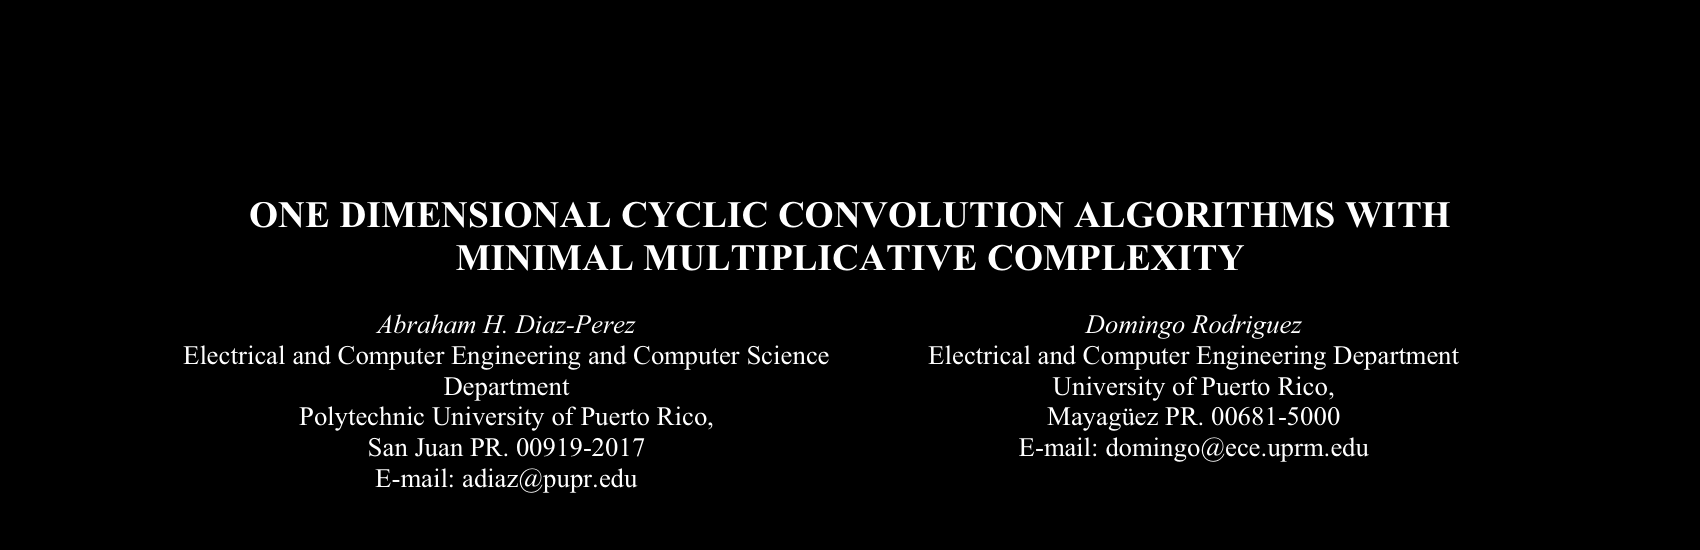

In [113]:
plot_pdf(doc[0], (0, .25))

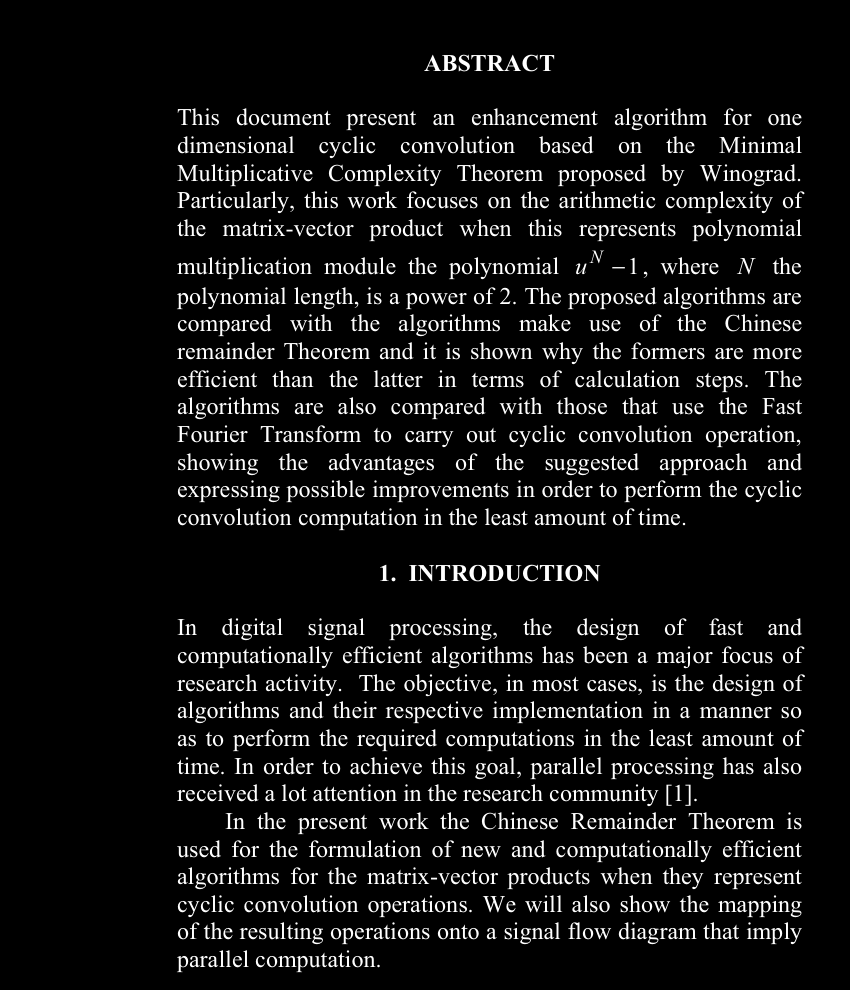

In [114]:
plot_pdf2col(doc[0], 0, [.23, .68])

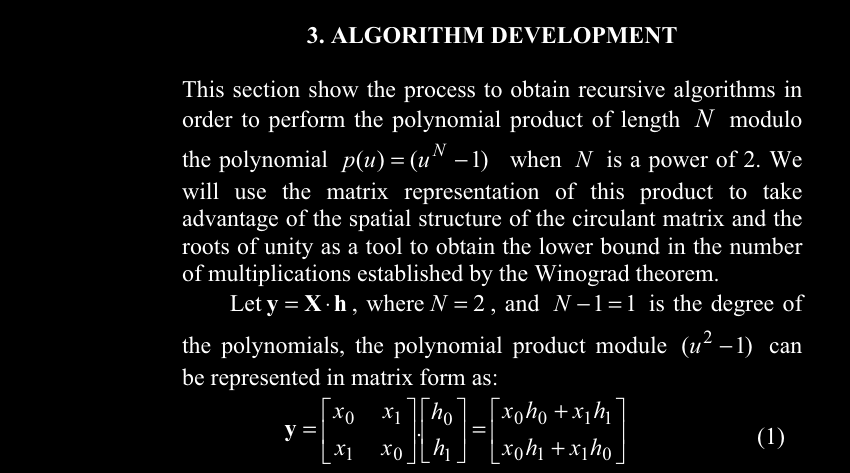

In [115]:
plot_pdf2col(doc[1], 0, [.465, .68])

Size of vectors

In [116]:
x_num = 2
h_num = 2

Example of vectors for the convolution

In [117]:
x_values = list(range(1, x_num+1))
h_values = list(range(1, x_num+1))
print(x_values, h_values)

[1, 2] [1, 2]


Polynomial degree

In [118]:
x_degree = x_num - 1
h_degree = x_num - 1
print(x_degree, h_degree)

1 1


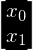

In [119]:
x = sy.Matrix(sy.symbols(" ".join(f"x_{i}"for i in range(x_num))))
x

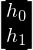

In [120]:
h = sy.Matrix(sy.symbols(" ".join(f"h_{i}"for i in range(h_num))))
h

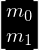

In [121]:
m = sy.Matrix(sy.symbols(" ".join(f"m_{i}"for i in range(h_num))))
m

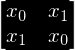

In [190]:
mx = sy.Matrix([
    [x[0], x[1]],
    [x[1], x[0]],
])
mx

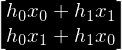

In [191]:
mx*h

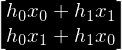

In [ ]:
sy.Matrix(symmetrical_cyclic_convolution(np.array(x).reshape(-1), np.array(h).reshape(-1)))

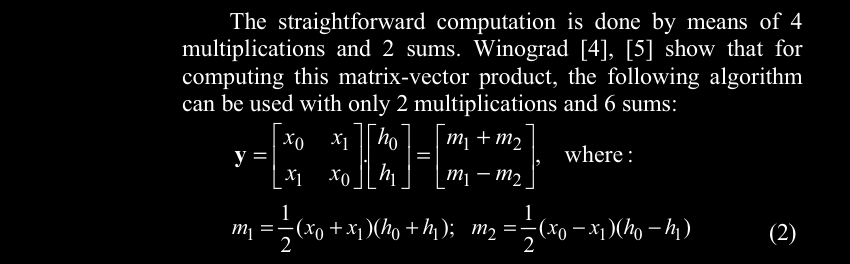

In [ ]:
plot_pdf2col(doc[1], 0, [.68, .8])

In [197]:
def winog2(x, h):
    a0 = x[0]+x[1]
    a1 = x[0]-x[1]
    b0 = (h[0]+h[1])/2
    b1 = (h[0]-h[1])/2

    m0 = a0*b0
    m1 = a1*b1
    s0 = m0 + m1
    s1 = m0 - m1
    return sy.simplify(sy.Matrix([s0, s1]))

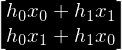

In [198]:
winog2(x, h)

In [289]:
def trf_inv2(x):
    x0 = x[0]+x[1]
    x1 = x[0]-x[1]
    return [x0, x1] 

In [311]:
trf = trf_inv2(x), trf_inv2(h)
trf

In [306]:
def trf_mult(a0, b0, c):
   return  [a * b/c for a, b in zip(a0, b0)]

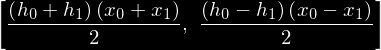

In [312]:
m = trf_mult(trf[0], trf[1], 2)
m

In [313]:
inv = trf_inv2(m)
sy.simplify(inv[0]), sy.simplify(inv[1])

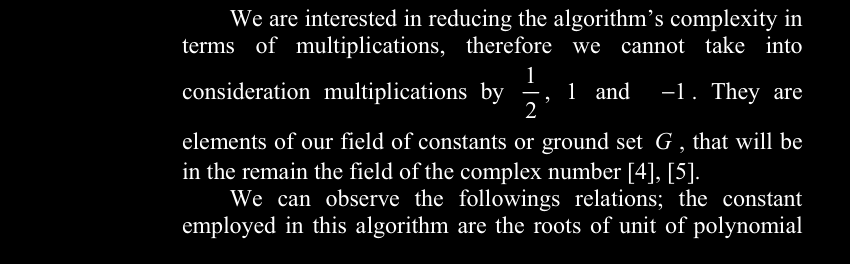

In [138]:
plot_pdf2col(doc[1], 0, [.8, .92])

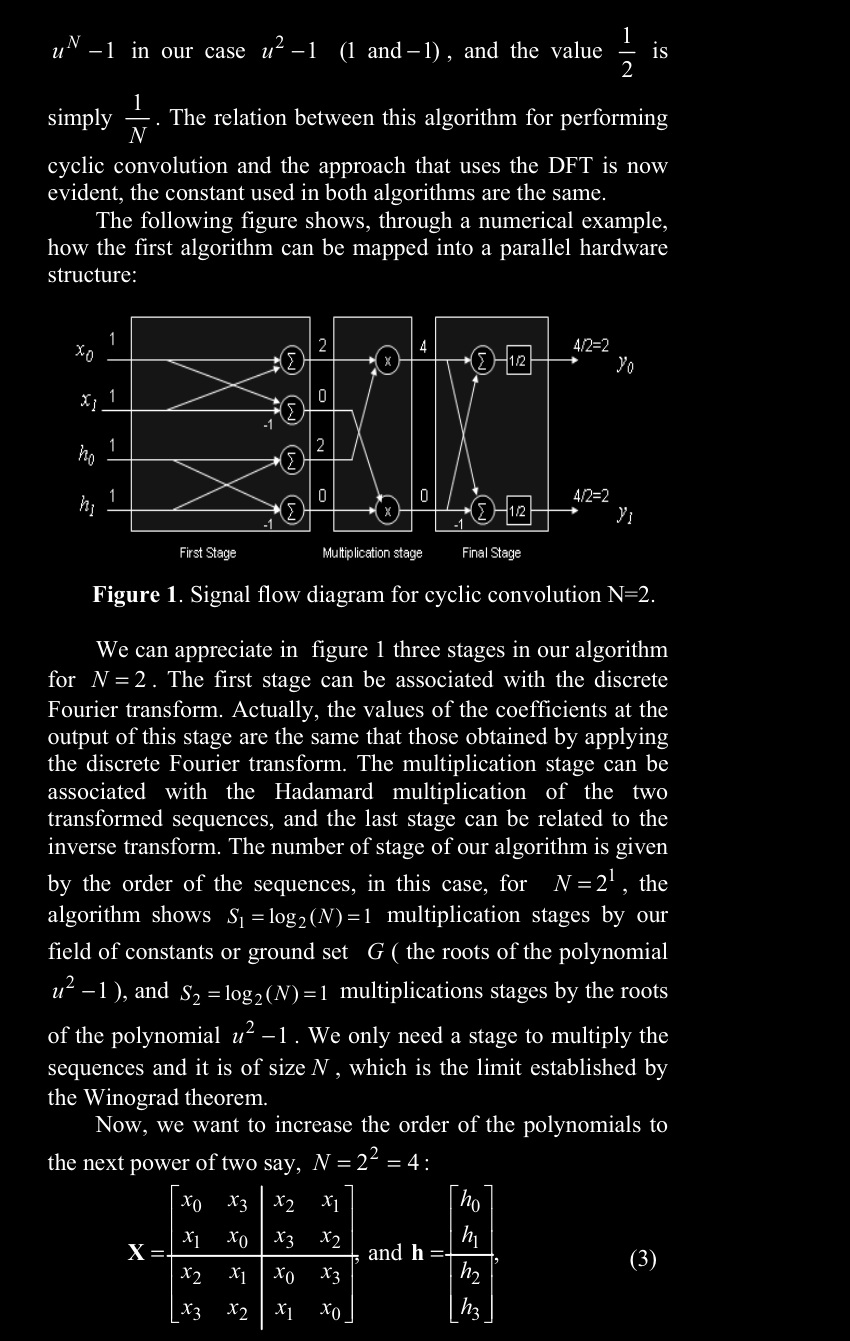

In [139]:
plot_pdf2col(doc[1], 1, [0.08, .69])

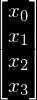

In [140]:
x0 = sy.Matrix(sy.symbols(" ".join(f"x_{i}"for i in range(x_num*2))))
x0

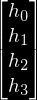

In [141]:
h0 = sy.Matrix(sy.symbols(" ".join(f"h_{i}"for i in range(h_num*2))))
h0

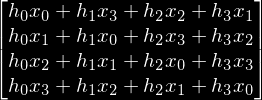

In [142]:
cc4 = sy.Matrix(symmetrical_cyclic_convolution(np.array(x0).reshape(-1), np.array(h0).reshape(-1)))
cc4

In [143]:
cc4_x0_args = [[arg for mul in line.args for arg in mul.args if 'x' in arg.name] for line in cc4]
cc4_x0_args

In [144]:
lst_x0 = [None, None]

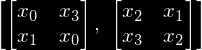

In [201]:
mx0 = [
    sy.Matrix(np.array(cc4_x0_args)[0:2, 0:2]),
    sy.Matrix(np.array(cc4_x0_args)[2:4, 0:2])
]
mx0

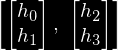

In [202]:
mh0 = [
    sy.Matrix(h0[0:2]),
    sy.Matrix(h0[2:4])
]
mh0

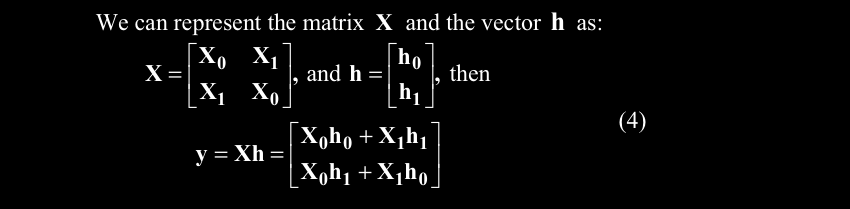

In [150]:
plot_pdf2col(doc[1], 1, [.685, .78])

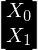

In [151]:
xx = sy.Matrix(sy.symbols(" ".join(f"X_{i}"for i in range(x_num))))
xx

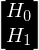

In [152]:
hh = sy.Matrix(sy.symbols(" ".join(f"H_{i}"for i in range(h_num))))
hh

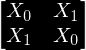

In [153]:
mxx = sy.Matrix([
    [xx[0], xx[1]],
    [xx[1], xx[0]],
])
mxx

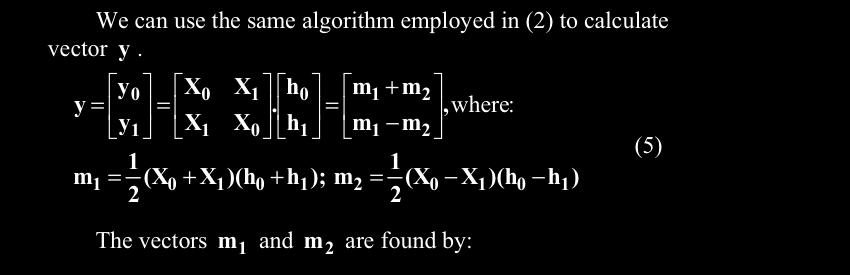

In [154]:
plot_pdf2col(doc[1], 1, [.775, .9])

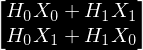

In [155]:
mxx*hh

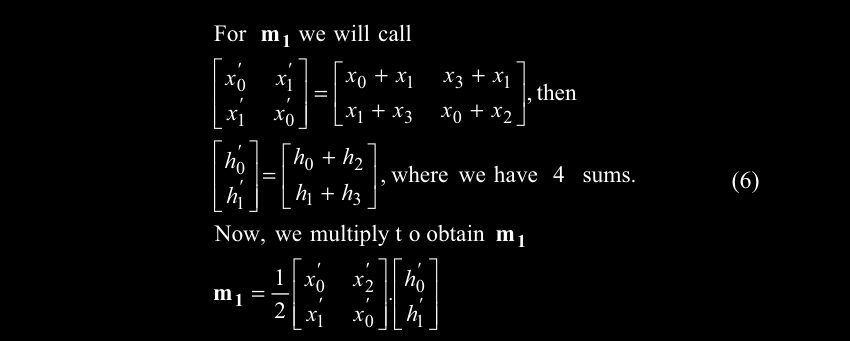

In [156]:
plot_pdf2col(doc[2], 0, [.08, .235])

In [230]:
trf = [
    mx0[0] + mx0[1],
    mx0[0] - mx0[1]
]

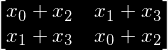

In [231]:
trf[0]

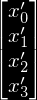

In [158]:
x1 = sy.Matrix(sy.symbols(" ".join(f"x'_{i}"for i in range(x_num*2))))
x1

In [216]:
mx1 = [
    sy.Matrix([
        [x1[0], x1[1]],
        [x1[1], x1[0]],
    ]),
    sy.Matrix([
        [x3], x1[2]],
    ])
]

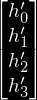

In [327]:
h1 = sy.Matrix(sy.symbols(" ".join(f"h'_{i}"for i in range(h_num*2))))
h1

In [343]:
mh1 = [
    sy.Matrix(h1[0:2]),
    sy.Matrix(h1[2:4]),
]

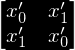

In [217]:
mx1[0]

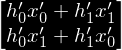

In [345]:
mx1[0] * mh1[0]

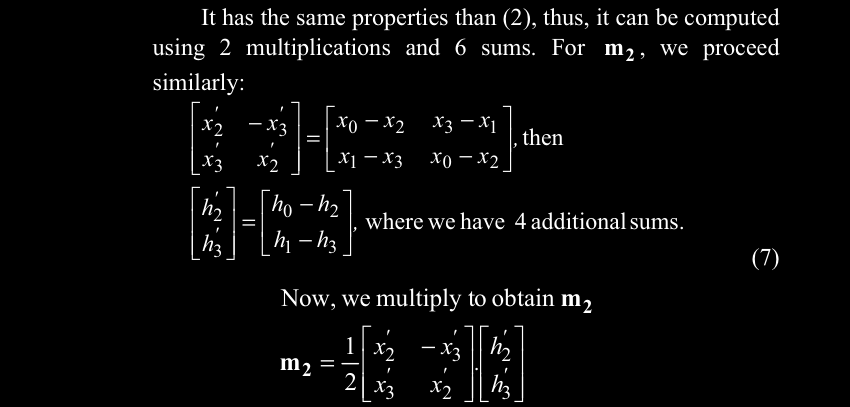

In [164]:
plot_pdf2col(doc[2], 0, [.235, .42])

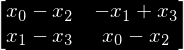

In [232]:
trf[1]

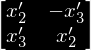

In [210]:
mx1[1]

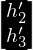

In [167]:
mh1[1]

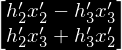

In [222]:
mx1[1] * mh1[1]

In [456]:
# def winog2(x, h):
a0 = x1[2]+I*x1[3]
a1 = x1[2]-I*x1[3]
b0 = (h1[2]+I*h1[3])
b1 = (h1[2]-I*h1[3])
a0, a1, b0, b1

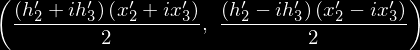

In [457]:
m0 = a0*b0/2
m1 = a1*b1/2
m0, m1

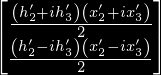

In [459]:
sy.simplify(sy.Matrix([m0, m1]))

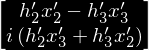

In [461]:
s0 = m0 + m1
s1 = m0 - m1

sy.simplify(sy.Matrix([s0, s1]))

In [464]:
-I*I

In [288]:
def trf_inv4(x):
    x0 = x[0] + x[2]
    x1 = x[1] + x[3]
    x2 = x[0] - x[2]
    x3 = x[1] - x[3]
    return [x0, x1, x2, x3]

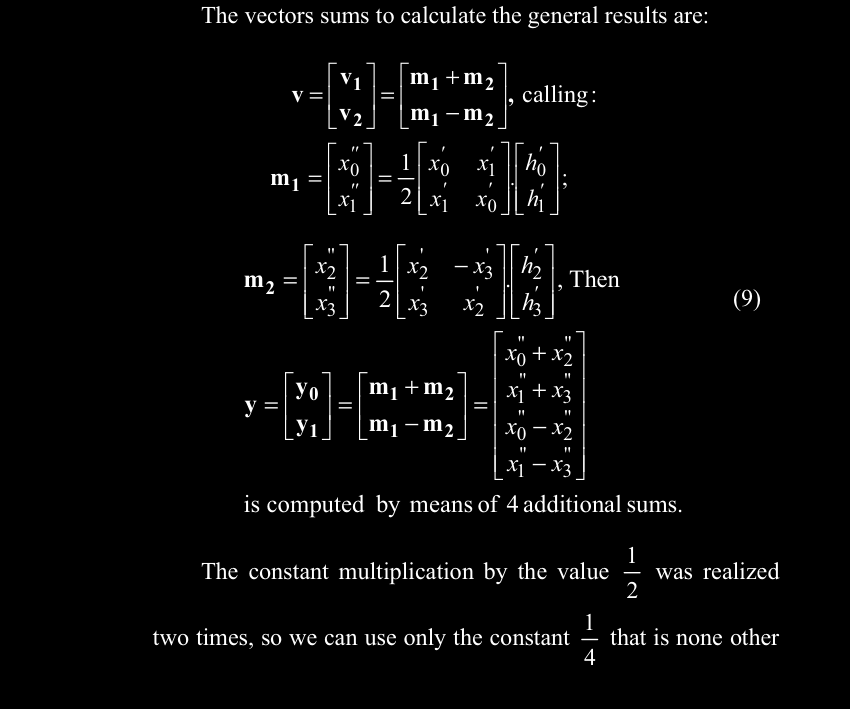

In [169]:
plot_pdf2col(doc[2], 0, [.598, .92])

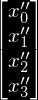

In [170]:
x2 = sy.Matrix(sy.symbols(" ".join(f"x''_{i}"for i in range(x_num*2))))
x2

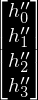

In [171]:
h2 = sy.Matrix(sy.symbols(" ".join(f"h''_{i}"for i in range(x_num*2))))
h2

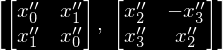

In [227]:
mx2 = [
    sy.Matrix([
        [x2[0], x2[1]],
        [x2[1], x2[0]],
    ]),
    sy.Matrix([
        [x2[2], - x2[3]],
        [x2[3], x2[2]],
    ])
]
mx2

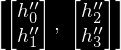

In [228]:
mh2 = [
    sy.Matrix(sy.symbols(" ".join(f"h''_{i}"for i in range(x_num)))),
    sy.Matrix(sy.symbols(" ".join(f"h''_{i}"for i in range(2, 2+ x_num))))
]
mh2

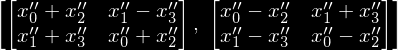

In [233]:
inv = [
    mx2[0] + mx2[1],
    mx2[0] - mx2[1]
]
inv

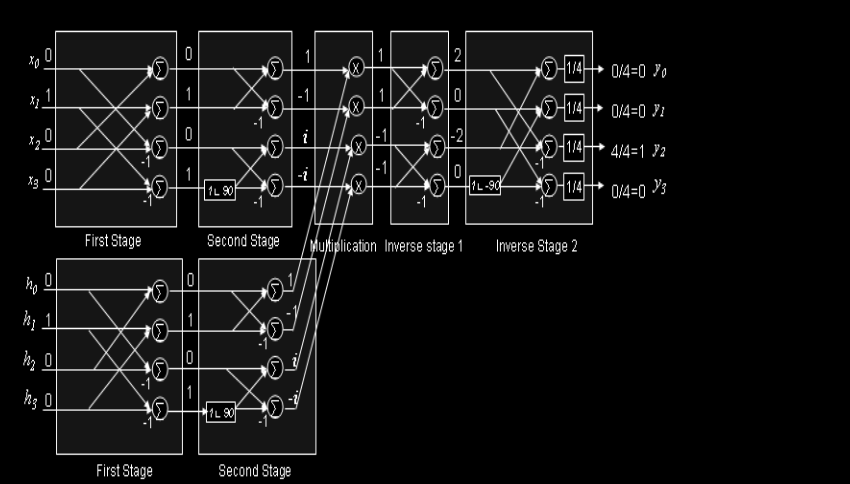

In [173]:
plot_pdf2col(doc[2], 1, [.13, .35])

In [433]:
x_values = [0, 1, 2, 3]
x_values

In [418]:
h_values = [0, 1, 0, 0]
h_values

In [434]:
t4 = trf_inv4(x_values)
t4

In [435]:
t2 = trf_inv2(t4[0:2]), trf_inv2([t4[2], 1j*t4[3]] )
t0 = [tt for t in t2 for tt in t]
t0

[6, -2, (-2-2j), (-2+2j)]

In [436]:
m0 = trf_mult(t0, t0, 1)
m0


[36.0, 4.0, 8j, -8j]

In [407]:
m0b = m0[0], m0[1], -1*m0[2], -1*m0[3]
m0b

In [440]:
inv2 = trf_inv2(m0[0:2]), trf_inv2([m0[2], 1j*m0[3]])
inv2 = [tt for t in inv2 for tt in t]
inv2

[40.0, 32.0, (8+8j), (-8+8j)]

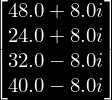

In [443]:
inv4 = trf_inv4(inv2)
sy.Matrix(np.array(inv4))

In [439]:
symmetrical_cyclic_convolution(x_values, h_values)